<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex05_HW_student_solution_KDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01ZLMA - Exercise 05: Homework

## Swedish Car Accidents - GLM Diagnostics

### Dataset

The `sweden2.csv` dataset contains annual data on road traffic deaths in Sweden:
- **Deaths**: number of road traffic deaths
- **Fuel**: annual volume of sold fuels (in 1000 m³)
- **Cars**: number of registered cars (in 1000s)
- **Year**: calendar year

In [385]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families import Poisson
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')

In [386]:

import io
import requests

url = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/sweden2.csv"
response = requests.get(url, verify=False)
cars = pd.read_csv(io.StringIO(response.text))
print(cars.tail())
print(f"\nShape: {cars.shape}")
print(cars.describe())



    Year  Deaths  Cars  Fuel
51  2006     445  4701  5363
52  2007     471  4782  5253
53  2008     397  4809  4930
54  2009     358  4837  4845
55  2010     266  4884  4550

Shape: (56, 4)
              Year       Deaths         Cars         Fuel
count    56.000000    56.000000    56.000000    56.000000
mean   1982.500000   850.178571  3152.892857  4412.178571
std      16.309506   292.008101  1179.482347  1308.771875
min    1955.000000   266.000000   755.000000  1531.000000
25%    1968.750000   582.250000  2318.250000  3589.000000
50%    1982.500000   828.500000  3182.500000  4839.500000
75%    1996.250000  1093.000000  3999.000000  5508.250000
max    2010.000000  1313.000000  4884.000000  5910.000000


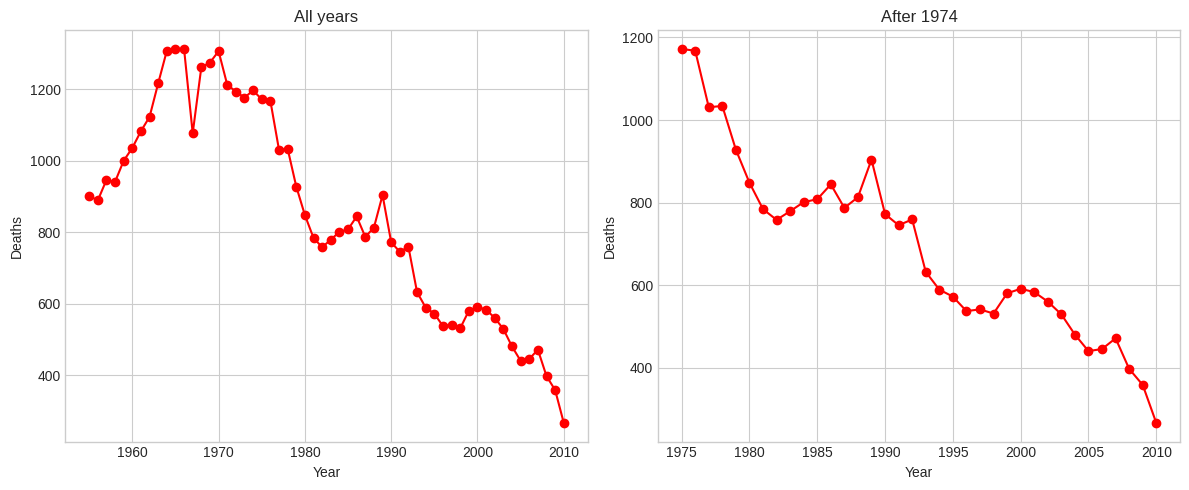

In [387]:


# Restrict to years after 1974 (structural change in traffic policy)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(cars['Year'], cars['Deaths'], 'ro-')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Deaths')
axes[0].set_title('All years')

cars = cars[cars['Year'] > 1974].reset_index(drop=True)
axes[1].plot(cars['Year'], cars['Deaths'], 'ro-')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Deaths')
axes[1].set_title('After 1974')
plt.tight_layout()
plt.show()



---
## Task 1: Explore the Data

Produce pair plots and correlation matrices. Which variables are most strongly associated with Deaths?

In [388]:
print(cars.describe())

              Year       Deaths         Cars         Fuel
count    36.000000    36.000000    36.000000    36.000000
mean   1992.500000   689.916667  3891.666667  5264.250000
std      10.535654   220.272866   622.931640   422.352958
min    1975.000000   266.000000  2931.000000  4383.000000
25%    1983.750000   535.500000  3284.250000  4896.000000
50%    1992.500000   688.500000  3918.500000  5392.500000
75%    2001.250000   809.250000  4438.000000  5580.250000
max    2010.000000  1172.000000  4884.000000  5910.000000


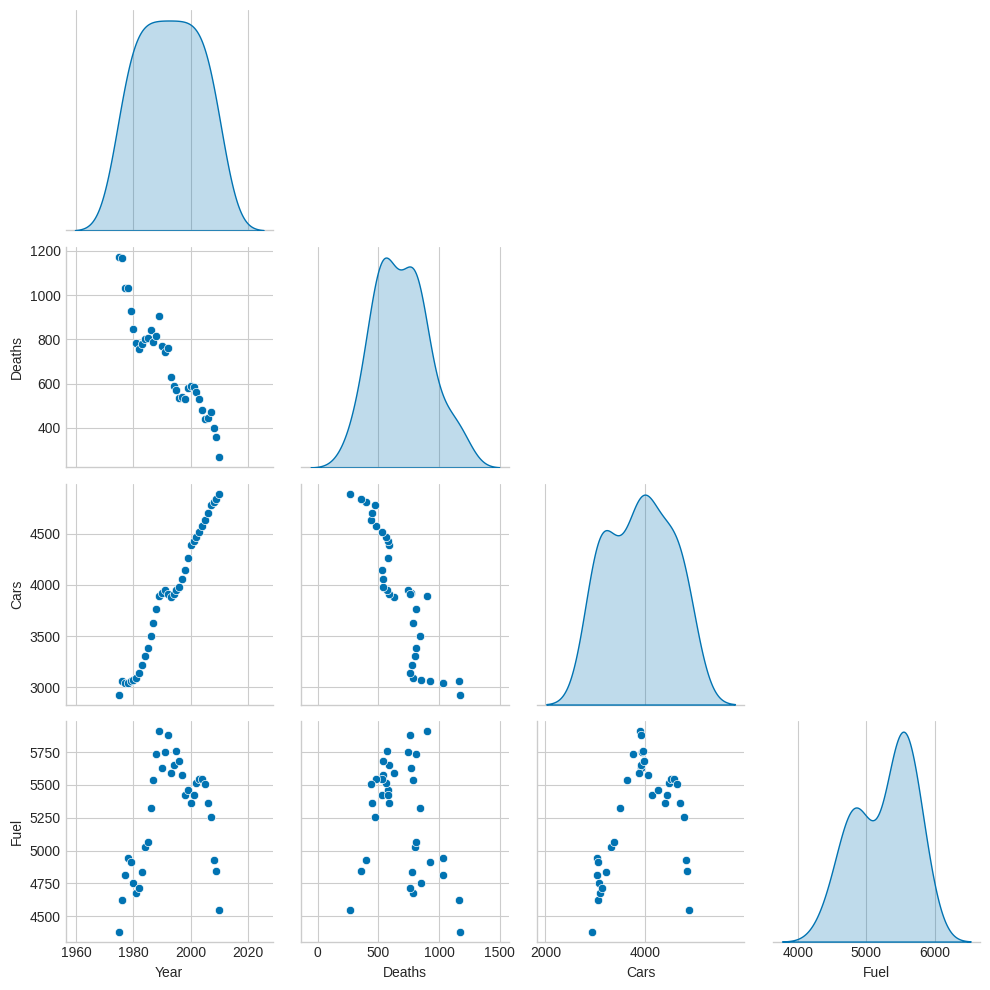

In [389]:
sns.pairplot(cars, diag_kind='kde', corner=True)
plt.tight_layout()
plt.show()

         Year  Deaths   Cars   Fuel
Year    1.000  -0.945  0.990  0.372
Deaths -0.945   1.000 -0.898 -0.304
Cars    0.990  -0.898  1.000  0.408
Fuel    0.372  -0.304  0.408  1.000


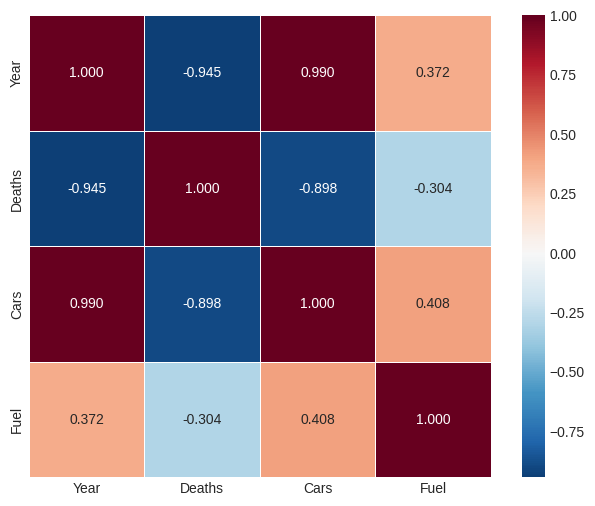

In [390]:
corr_matrix = cars.corr()
print(corr_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.show()

In [391]:

print("\nCorrelations with Deaths :")
death_corr = corr_matrix['Deaths'].drop('Deaths')
for var, r in death_corr.items():
    print(f"  {var}: {corr_matrix.loc['Deaths', var]:+.3f}")


Correlations with Deaths :
  Year: -0.945
  Cars: -0.898
  Fuel: -0.304



**Year** has the strongest correlation with Deaths (r = -0.945), indicating a strong decreasing trend in deaths over time (likely due to improved safety measures).

**Cars** also have a strong negative correlation (r = -0.898), but this is confounded with Year (more cars over time, but also better safety).

**Fuel** has a weaker negative correlation with Deaths (r = -0.304).

All of this is however just speculative due to high multicolinearity/correlation. Especially
Cars and Year are highly correlated (r = 0.990), indicating potential multicollinearity issues and maybe explaining the negative correlation of cars.


---
## Task 2: Fit a Poisson GLM

Start with a model including all available predictors. Justify the choice of distribution and link function.

### Justification for Poisson GLM

**Distribution choice - Poisson:**
Deaths are count data (non-negative integers)
and the Poisson distribution is the natural choice for modeling "unbounded" counts. There is however overdispersion present in the data contradicting the
assumptions about the known poisson parameter.

**Link function - Log (canonical):**
The log link is the canonical link for Poisson
and it ensures predicted counts are always positive: $\mu = \exp(\eta) > 0$. The coefficients have a multiplicative interpretation, where $\exp(\beta_j)$ is the multiplicative change in expected deaths for a unit increase in $x_j$ - if the link is choosen wrong, it should be visible on the diagnostics and the changed appropriately.

In [392]:

model_full = smf.glm('Deaths ~ Fuel + Cars + Year',
                     data=cars,
                     family=sm.families.Poisson()).fit()
print(model_full.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Deaths   No. Observations:                   36
Model:                            GLM   Df Residuals:                       32
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -190.75
Date:                Tue, 07 Apr 2026   Deviance:                       81.904
Time:                        20:37:48   Pearson chi2:                     80.4
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    153.9859      8.178     18.830      0.0

In [393]:
# Check for overdispersion
# Pearson chi-squared / df should be close to 1 for Poisson
pearson_chi2 = model_full.pearson_chi2
df_resid = model_full.df_resid
dispersion = pearson_chi2 / df_resid

print(f"Pearson Chi-squared: {pearson_chi2:.2f}")
print(f"Residual df: {df_resid}")
print(f"Estimated dispersion: {dispersion:.3f}")



Pearson Chi-squared: 80.36
Residual df: 32
Estimated dispersion: 2.511


---
## Task 3: Model Selection

Try adding interactions (up to second order) and use AIC-based selection to find the best model.

In [394]:
models = {}

# Main effects only
models[0] = smf.glm('Deaths ~ Fuel', data=cars, family=sm.families.Poisson()).fit()
models[1] = smf.glm('Deaths ~ Year', data=cars, family=sm.families.Poisson()).fit()
models[2] = smf.glm('Deaths ~ Cars', data=cars, family=sm.families.Poisson()).fit()
models[3] = smf.glm('Deaths ~ Fuel + Year', data=cars, family=sm.families.Poisson()).fit()
models[4] = smf.glm('Deaths ~ Fuel + Cars', data=cars, family=sm.families.Poisson()).fit()
models[5] = smf.glm('Deaths ~ Year + Cars', data=cars, family=sm.families.Poisson()).fit()
models[6] = model_full

# With interactions
models[7] = smf.glm('Deaths ~ Fuel * Year', data=cars, family=sm.families.Poisson()).fit()
models[8] = smf.glm('Deaths ~ Fuel * Cars', data=cars, family=sm.families.Poisson()).fit()
models[9] = smf.glm('Deaths ~ Year * Cars', data=cars, family=sm.families.Poisson()).fit()

# Full interaction model
models[10] = smf.glm('Deaths ~ Fuel * Year + Cars', data=cars, family=sm.families.Poisson()).fit()
models[11] = smf.glm('Deaths ~ Fuel + Year * Cars', data=cars, family=sm.families.Poisson()).fit()
models[12] = smf.glm('Deaths ~ Fuel * Cars + Year', data=cars, family=sm.families.Poisson()).fit()


In [395]:
comparison = pd.DataFrame({
    'Model': list(models.keys()),
    'AIC': [m.aic for m in models.values()],
    'Deviance': [m.deviance for m in models.values()],
    'df_resid': [int(m.df_resid) for m in models.values()],
    'n_params': [m.df_model + 1 for m in models.values()]
}).sort_values('AIC').reset_index(drop=True)

comparison['Delta_AIC'] = comparison['AIC'] - comparison['AIC'].min()

print("Model Comparison (sorted by AIC):")
print(comparison.to_string(index=False))
print(f"\nBest model by AIC: {comparison.iloc[0]['Model']}")

Model Comparison (sorted by AIC):
 Model         AIC    Deviance  df_resid  n_params   Delta_AIC
    10  367.907508   58.303437        31         5    0.000000
    12  369.521715   59.917644        31         5    1.614207
     6  389.507922   81.903851        32         4   21.600414
    11  390.525218   80.921147        31         5   22.617710
     9  395.077653   87.473582        32         4   27.170145
     5  405.187356   99.583285        33         3   37.279847
     7  470.090753  162.486682        32         4  102.183245
     3  494.163514  188.559443        33         3  126.256006
     1  561.050138  257.446067        34         2  193.142630
     8  652.971572  345.367501        32         4  285.064064
     4  703.744736  398.140665        33         3  335.837228
     2  779.993726  476.389655        34         2  412.086218
     0 2552.000333 2248.396262        34         2 2184.092825

Best model by AIC: 10.0


In [396]:
best_model_name = comparison.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Selected model: {best_model_name}")
print(best_model.summary())

Selected model: 10.0
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Deaths   No. Observations:                   36
Model:                            GLM   Df Residuals:                       31
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -178.95
Date:                Tue, 07 Apr 2026   Deviance:                       58.303
Time:                        20:37:48   Pearson chi2:                     58.3
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    251.1065     21.62

The models 10 and 12 are very similar in their results, but that is no surprise, with cars and year being highly correlated. The AIC best model is the one with year and fuel interaction, but it is highly "physically" probable, that the real interaction is fuel*cars, but the correlaton between cars and year "flukes" the AIC somehow into choosing the other one.

---
## Task 4: Diagnostics

For the selected model, produce:
- Residuals vs fitted values and vs each covariate
- Working response plot (link function validation)
- Q-Q plot
- Influence diagnostics (Cook's distance, leverage)

In [397]:
# Extract residuals and fitted values
fitted = best_model.fittedvalues
linear_pred = best_model.predict(which='linear')

resid_response = best_model.resid_response
resid_pearson = best_model.resid_pearson
resid_deviance = best_model.resid_deviance

influence = best_model.get_influence()
leverage = influence.hat_matrix_diag
resid_std = resid_pearson / np.sqrt(1 - leverage)

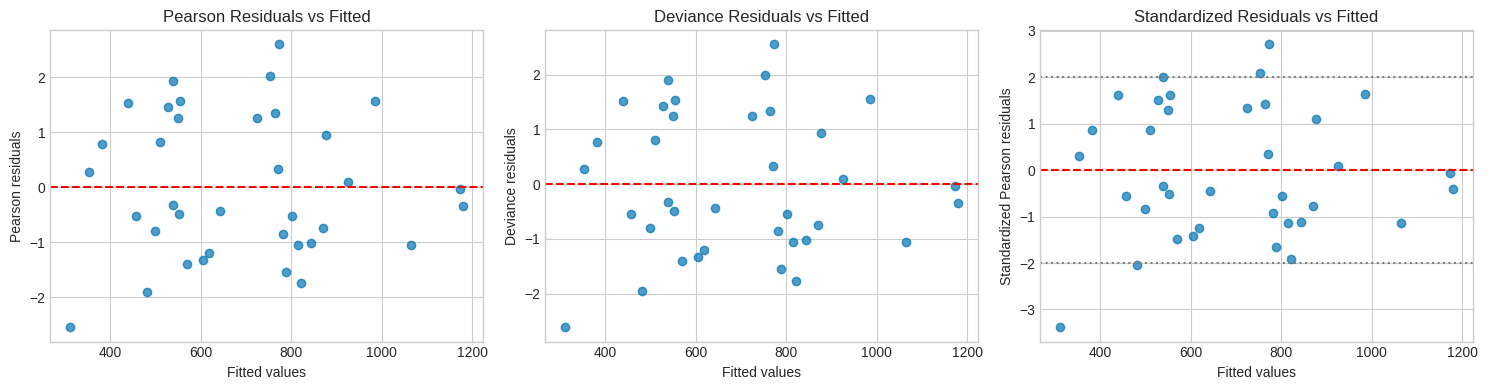

In [398]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pearson residuals
axes[0].scatter(fitted, resid_pearson, alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Pearson residuals')
axes[0].set_title('Pearson Residuals vs Fitted')

# Deviance residuals
axes[1].scatter(fitted, resid_deviance, alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Deviance residuals')
axes[1].set_title('Deviance Residuals vs Fitted')

# Standardized residuals
axes[2].scatter(fitted, resid_std, alpha=0.7)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].axhline(y=2, color='gray', linestyle=':')
axes[2].axhline(y=-2, color='gray', linestyle=':')
axes[2].set_xlabel('Fitted values')
axes[2].set_ylabel('Standardized Pearson residuals')
axes[2].set_title('Standardized Residuals vs Fitted')

plt.tight_layout()
plt.show()

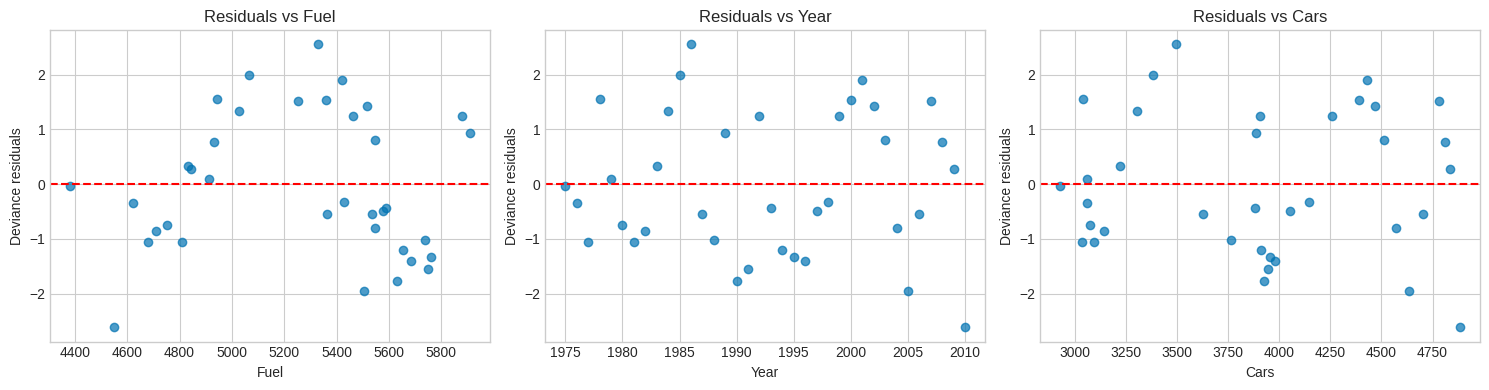

In [399]:

covariates = ['Fuel', 'Year', 'Cars']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, cov in enumerate(covariates):
    axes[i].scatter(cars[cov], resid_deviance, alpha=0.7)
    axes[i].axhline(y=0, color='red', linestyle='--')
    axes[i].set_xlabel(cov)
    axes[i].set_ylabel('Deviance residuals')
    axes[i].set_title(f'Residuals vs {cov}')

plt.tight_layout()
plt.show()

There is a curvature pattern across Fuel values.
This may suggest a non-linear relationship between Fuel and the response that isn't fully captured by the current model. The residuals go
negative at low Fuel (around 4400-4600)
positive in the middle (around 4800-5200)
negative again, then positive at high Fuel (arund 5400-5800). This also makes
sense in the context of the corrrelation of fuel with year - first, the cars were consuming more and more fuel as more and more cars got onto roads and then
the cars started getting more efficient so the fuel ussage dropped again.



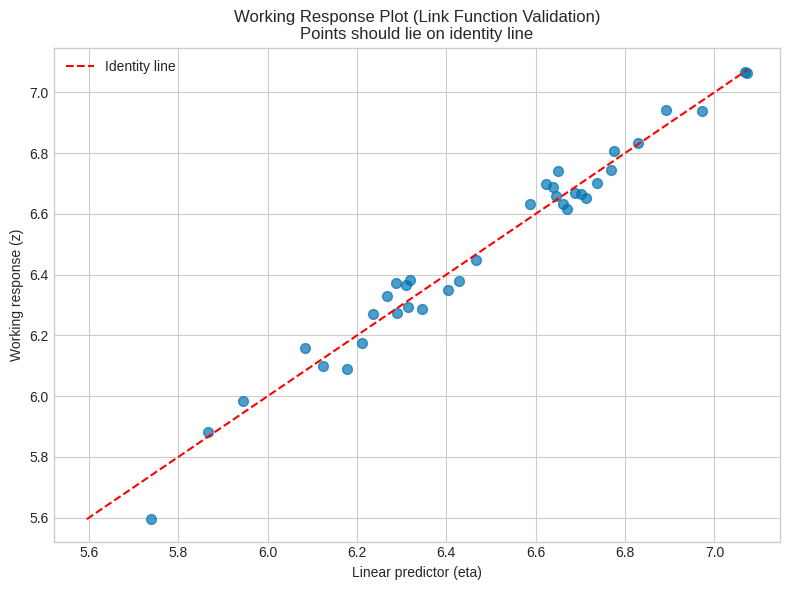

Correlation between linear predictor and working response: 0.9871
(Should be close to 1 if link function is appropriate)


In [400]:
# Working response: z = eta + (y - mu) * d(eta)/d(mu)
# For log link: d(eta)/d(mu) = 1/mu, so z = eta + (y - mu)/mu

working_response = linear_pred + (cars['Deaths'] - fitted) / fitted

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(linear_pred, working_response, alpha=0.7, s=50)

lims = [min(linear_pred.min(), working_response.min()),
        max(linear_pred.max(), working_response.max())]
ax.plot(lims, lims, 'r--', label='Identity line')

ax.set_xlabel('Linear predictor (eta)')
ax.set_ylabel('Working response (z)')
ax.set_title('Working Response Plot (Link Function Validation)\nPoints should lie on identity line')
ax.legend()
plt.tight_layout()
plt.show()

corr = np.corrcoef(linear_pred, working_response)[0, 1]
print(f"Correlation between linear predictor and working response: {corr:.4f}")
print("(Should be close to 1 if link function is appropriate)")

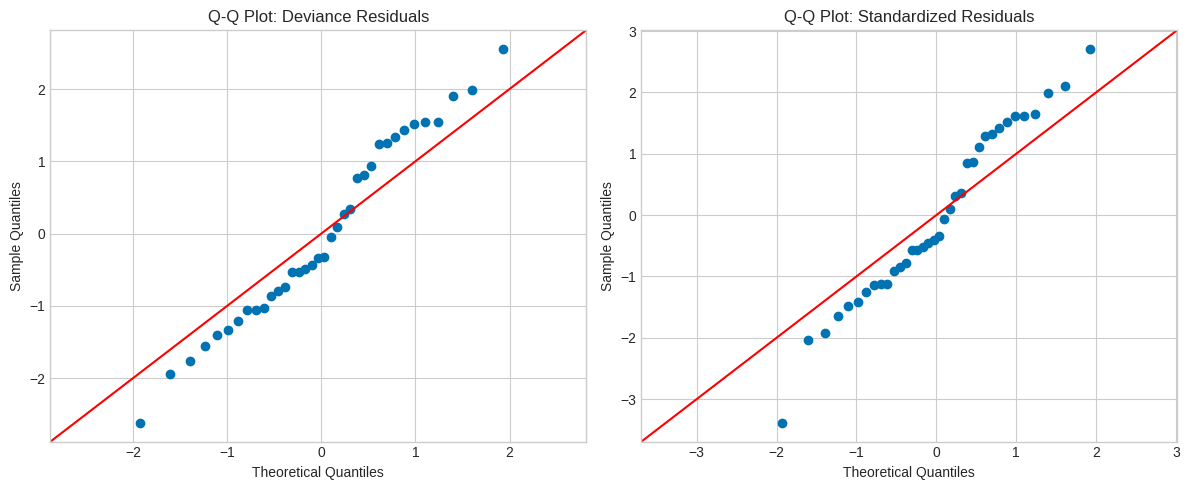

In [401]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sm.qqplot(resid_deviance, line='45', ax=axes[0])
axes[0].set_title('Q-Q Plot: Deviance Residuals')

sm.qqplot(resid_std, line='45', ax=axes[1])
axes[1].set_title('Q-Q Plot: Standardized Residuals')

plt.tight_layout()
plt.show()


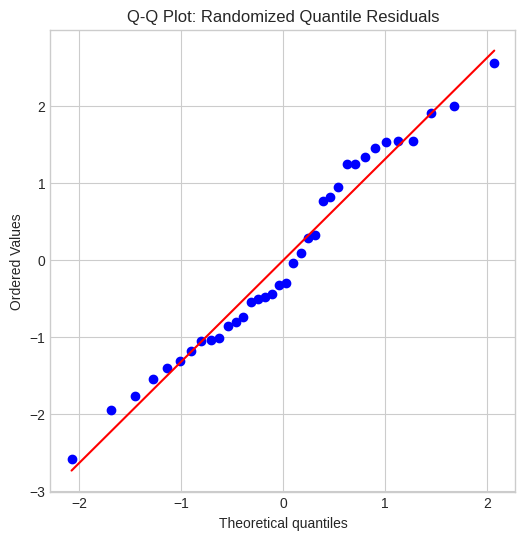

Shapiro-Wilk test: W = 0.9678, p-value = 0.3677


In [402]:
from scipy import stats

y = cars['Deaths'].values
mu = best_model.fittedvalues.values

u = np.random.uniform(
    stats.poisson.cdf(y - 1, mu),
    stats.poisson.cdf(y, mu)
)
rqr = stats.norm.ppf(u)

fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(rqr, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Randomized Quantile Residuals')
plt.show()

stat, p_value = stats.shapiro(rqr)
print(f"Shapiro-Wilk test: W = {stat:.4f}, p-value = {p_value:.4f}")

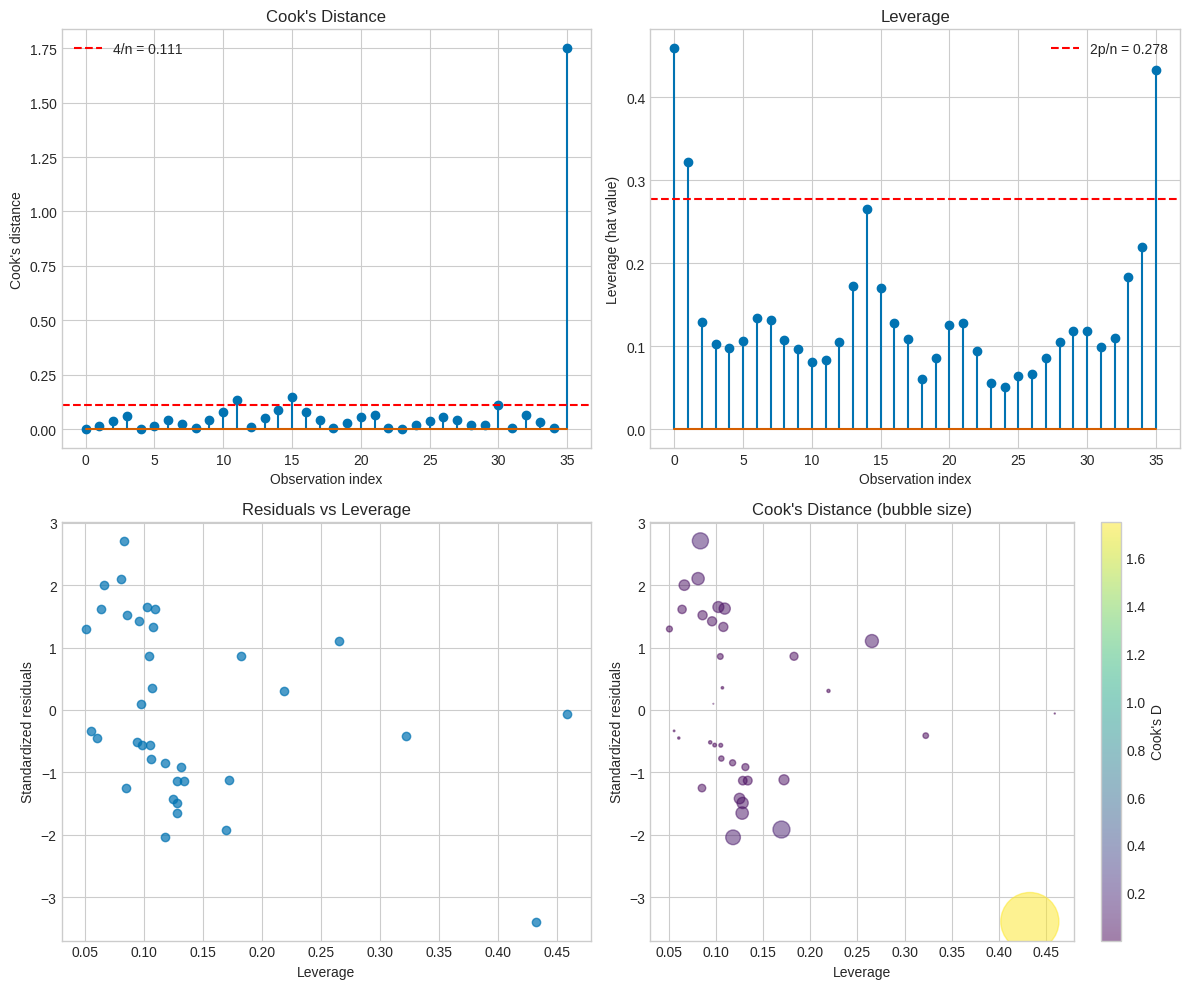

In [403]:
cooks_d = influence.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Cooks distance
axes[0, 0].stem(range(len(cooks_d)), cooks_d, markerfmt='o')
axes[0, 0].axhline(y=4/len(cooks_d), color='red', linestyle='--', label=f'4/n = {4/len(cooks_d):.3f}')
axes[0, 0].set_xlabel('Observation index')
axes[0, 0].set_ylabel("Cook's distance")
axes[0, 0].set_title("Cook's Distance")
axes[0, 0].legend()

# Leverage
axes[0, 1].stem(range(len(leverage)), leverage, markerfmt='o')
p = best_model.df_model + 1
n = len(cars)
axes[0, 1].axhline(y=2*p/n, color='red', linestyle='--', label=f'2p/n = {2*p/n:.3f}')
axes[0, 1].set_xlabel('Observation index')
axes[0, 1].set_ylabel('Leverage (hat value)')
axes[0, 1].set_title('Leverage')
axes[0, 1].legend()

# Residuals vs Leverage
axes[1, 0].scatter(leverage, resid_std, alpha=0.7)
axes[1, 0].set_xlabel('Leverage')
axes[1, 0].set_ylabel('Standardized residuals')
axes[1, 0].set_title('Residuals vs Leverage')

# Cookw distance vs Leverage
scatter = axes[1, 1].scatter(leverage, resid_std, s=1000*cooks_d, alpha=0.5, c=cooks_d, cmap='viridis')
axes[1, 1].set_xlabel('Leverage')
axes[1, 1].set_ylabel('Standardized residuals')
axes[1, 1].set_title("Cook's Distance (bubble size)")
plt.colorbar(scatter, ax=axes[1, 1], label="Cook's D")

plt.tight_layout()
plt.show()

The year 2010 has a very low ammount of eaths and a very high leverage with a high residual. This could reflect a real structural change. Perhaps new safety regulations, technology or driving behavior shifts around 2008-2010. Or we are just hitting the limits of the model.

In [404]:
# Identify influential observations
threshold_cooks = 4 / n
threshold_leverage = 2 * p / n

influential_cooks = np.where(cooks_d > threshold_cooks)[0]
influential_leverage = np.where(leverage > threshold_leverage)[0]

print("Potentially influential observations:")
print(f"\nHigh Cook's distance (> {threshold_cooks:.3f}):")
if len(influential_cooks) > 0:
    for idx in influential_cooks:
        print(f"  Obs {idx}: Year={cars.iloc[idx]['Year']}, Deaths={cars.iloc[idx]['Deaths']}, Cook's D={cooks_d[idx]:.4f}")
else:
    print("  None")

print(f"\nHigh leverage (> {threshold_leverage:.3f}):")
if len(influential_leverage) > 0:
    for idx in influential_leverage:
        print(f"  Obs {idx}: Year={cars.iloc[idx]['Year']}, Deaths={cars.iloc[idx]['Deaths']}, Leverage={leverage[idx]:.4f}")
else:
    print("  None")

Potentially influential observations:

High Cook's distance (> 0.111):
  Obs 11: Year=1986, Deaths=844, Cook's D=0.1340
  Obs 15: Year=1990, Deaths=772, Cook's D=0.1496
  Obs 30: Year=2005, Deaths=440, Cook's D=0.1116
  Obs 35: Year=2010, Deaths=266, Cook's D=1.7498

High leverage (> 0.278):
  Obs 0: Year=1975, Deaths=1172, Leverage=0.4590
  Obs 1: Year=1976, Deaths=1168, Leverage=0.3224
  Obs 35: Year=2010, Deaths=266, Leverage=0.4326


---
## Task 5: Interpret the Final Model

What are the significant predictors? How do you interpret the coefficients?

In [405]:
# Model summary
print("Final Model Summary:")
print(best_model.summary())

Final Model Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Deaths   No. Observations:                   36
Model:                            GLM   Df Residuals:                       31
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -178.95
Date:                Tue, 07 Apr 2026   Deviance:                       58.303
Time:                        20:37:50   Pearson chi2:                     58.3
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    251.1065     21.62

In [406]:

params = best_model.params
conf_int = best_model.conf_int()
pvalues = best_model.pvalues

for name in params.index:
    beta = params[name]
    exp_beta = np.exp(beta)
    ci_low, ci_high = conf_int.loc[name]
    p = pvalues[name]

    print(f"\n{name}:")
    print(f"  beta = {beta:.4f}, exp(beta) = {exp_beta:.4f}")
    print(f"  95% CI for beta: [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"  95% CI for exp(beta): [{np.exp(ci_low):.4f}, {np.exp(ci_high):.4f}]")
    print(f"  p-value: {p:.4f}")

    if name != 'Intercept':
        if exp_beta > 1:
            pct_change = (exp_beta - 1) * 100
            print(f"A unit increase in {name} is associated with a {pct_change:.4f}% increase in expected deaths")
        else:
            pct_change = (1 - exp_beta) * 100
            print(f" A unit increase in {name} is associated with a {pct_change:.4f}% decrease in expected deaths")


Intercept:
  beta = 251.1065, exp(beta) = 11328309920121841684079951479931065485024169500177922409478312187465923755649466959041515014983568623159738368.0000
  95% CI for beta: [208.7284, 293.4846]
  95% CI for exp(beta): [4462693933608146975974166074801869774571391478429063583900867878761386814474534590053613568.0000, 28756308981865110615942741144539147089729962629750817942943638952942893653492568697754353132920739143592600730455649173049966592.0000]
  p-value: 0.0000

Fuel:
  beta = -0.0194, exp(beta) = 0.9808
  95% CI for beta: [-0.0273, -0.0115]
  95% CI for exp(beta): [0.9731, 0.9885]
  p-value: 0.0000
 A unit increase in Fuel is associated with a 1.9230% decrease in expected deaths

Year:
  beta = -0.1246, exp(beta) = 0.8829
  95% CI for beta: [-0.1460, -0.1032]
  95% CI for exp(beta): [0.8642, 0.9020]
  p-value: 0.0000
 A unit increase in Year is associated with a 11.7120% decrease in expected deaths

Fuel:Year:
  beta = 0.0000, exp(beta) = 1.0000
  95% CI for beta: [0.0000, 0.

Giant numbers for intercept - nothing weird, but the intercept here has really no real practical itnerpretation. That would come with centered covariates.

Coefficient Interpretation (Log Link):

For a Poisson GLM with log link: $log(\mu) = \eta = \beta_0 + \beta_1 x_1 +
\beta_2 x_2 + ...$
So $\mu = exp(\eta) = exp(\beta_0)  exp(\beta_1 x_1)  exp(\beta_2 x_2)  ...$
$exp(\beta_j)$ represents the multiplicative change in expected count for a unit increase in $x_j$ (holding others constant).



In [407]:
# Goodness of fit
print("\nGoodness of Fit:")
print(f"Deviance: {best_model.deviance}")
print(f"Residual df: {best_model.df_resid}")
print(f"Pearson chi-squared: {best_model.pearson_chi2}")
print(f"Estimated dispersion: {best_model.pearson_chi2 / best_model.df_resid}")
print(f"AIC: {best_model.aic}")


Goodness of Fit:
Deviance: 58.30343711600973
Residual df: 31
Pearson chi-squared: 58.27557985717541
Estimated dispersion: 1.8798574147475937
AIC: 367.9075080897728


---
## Task 6: Predictions

Plot the predicted Deaths over the years and compare with observed values.

In [408]:
# Predictions with confidence intervals
pred = best_model.get_prediction(cars)
pred_summary = pred.summary_frame(alpha=0.05)

results = pd.DataFrame({
    'Year': cars['Year'],
    'Observed': cars['Deaths'],
    'Predicted': pred_summary['mean'].round(1),
    'CI_low': pred_summary['mean_ci_lower'].round(1),
    'CI_high': pred_summary['mean_ci_upper'].round(1),
    'Residual': (cars['Deaths'] - pred_summary['mean']).round(1)
})
print("Predictions:")
print(results.to_string(index=False))

Predictions:
 Year  Observed  Predicted  CI_low  CI_high  Residual
 1975      1172     1173.4  1128.8   1219.8      -1.4
 1976      1168     1179.6  1142.0   1218.5     -11.6
 1977      1031     1065.5  1042.8   1088.7     -34.5
 1978      1034      985.0   965.5   1004.9      49.0
 1979       928      925.1   906.7    943.9       2.9
 1980       848      869.7   851.1    888.7     -21.7
 1981       784      814.0   793.8    834.7     -30.0
 1982       758      781.8   762.2    801.9     -23.8
 1983       779      769.7   752.1    787.7       9.3
 1984       801      763.7   747.1    780.7      37.3
 1985       808      752.7   737.5    768.2      55.3
 1986       844      772.0   756.4    787.9      72.0
 1987       787      802.1   784.3    820.4     -15.1
 1988       813      842.5   819.2    866.5     -29.5
 1989       904      876.0   846.6    906.4      28.0
 1990       772      822.0   799.2    845.5     -50.0
 1991       745      788.3   768.8    808.2     -43.3
 1992       759

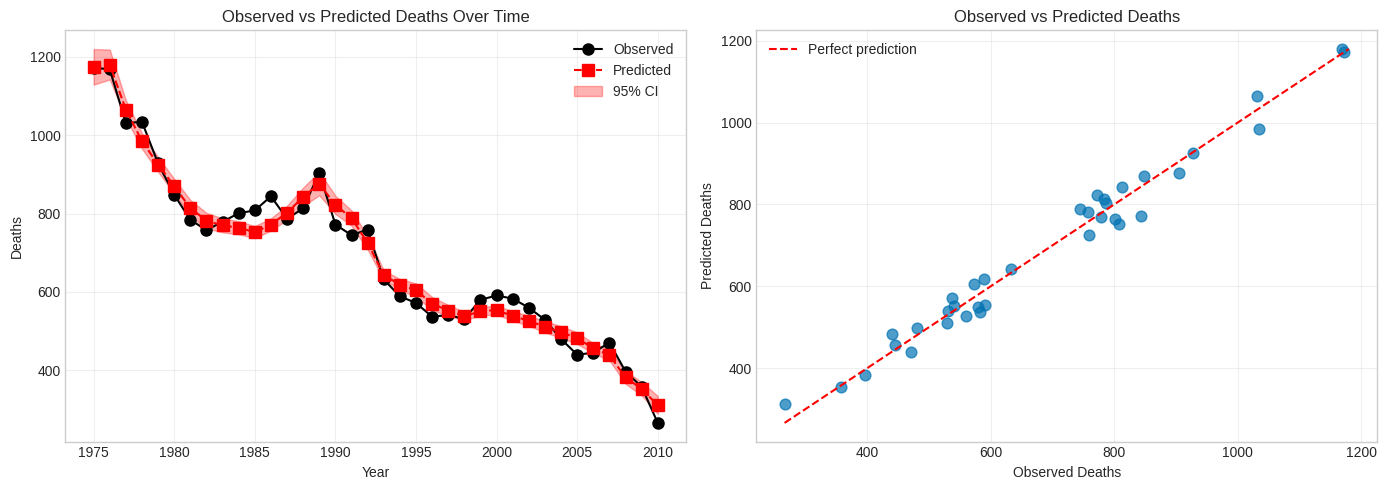

In [409]:
# Plot predictions vs observed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cars['Year'], cars['Deaths'], 'ko-', label='Observed', markersize=8)
axes[0].plot(cars['Year'], pred_summary['mean'], 'rs--', label='Predicted', markersize=8)
axes[0].fill_between(cars['Year'],
                     pred_summary['mean_ci_lower'],
                     pred_summary['mean_ci_upper'],
                     alpha=0.3, color='red', label='95% CI')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Deaths')
axes[0].set_title('Observed vs Predicted Deaths Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Observed vs Predicted scatter
axes[1].scatter(cars['Deaths'], pred_summary['mean'], s=60, alpha=0.7)
min_val = min(cars['Deaths'].min(), pred_summary['mean'].min())
max_val = max(cars['Deaths'].max(), pred_summary['mean'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Observed Deaths')
axes[1].set_ylabel('Predicted Deaths')
axes[1].set_title('Observed vs Predicted Deaths')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()